# Stock 7 Analysis

Building bid/ask quotes for stock 7. Trying different models, checking residuals, then using conformal prediction to set the spread.

## Section 1: Setup & Data Loading

Loading in the data and setting everything up.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, train_test_split, LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = 'hackathon_data'
RNG = np.random.RandomState(42)
STOCK_ID = 7

In [2]:
# Load the training and test CSV files for stock 7
train_df = pd.read_csv(DATA_DIR + '/stock_7_train.csv')
test_df = pd.read_csv(DATA_DIR + '/stock_7_test.csv')

# Get feature columns (all columns except target) - using a loop, not list comprehension
feature_columns = []
for col in train_df.columns:
    if col != 'target':
        feature_columns.append(col)

X_train = train_df[feature_columns].values
y_train = train_df['target'].values
X_test = test_df[feature_columns].values

number_of_samples = len(y_train)
number_of_features = len(feature_columns)
print("Loaded stock 7 training data with", number_of_samples, "rows and", number_of_features, "features")
print("Test data has", len(X_test), "rows")

Loaded stock 7 training data with 19999 rows and 25 features
Test data has 1 rows


In [3]:
# Print summary statistics so we understand the data before modelling
target_mean = y_train.mean()
target_std = y_train.std()
target_min = y_train.min()
target_max = y_train.max()
target_kurtosis = stats.kurtosis(y_train)
target_skewness = stats.skew(y_train)

print("Summary Statistics for Stock 7 Target")
print("="*40)
print("Mean:    ", round(target_mean, 2))
print("Std:     ", round(target_std, 2))
print("Min:     ", round(target_min, 2))
print("Max:     ", round(target_max, 2))
print("Kurtosis:", round(target_kurtosis, 2))
print("Skewness:", round(target_skewness, 2))

Summary Statistics for Stock 7 Target
Mean:     211.04
Std:      15.84
Min:      80.0
Max:      400.0
Kurtosis: 7.0
Skewness: 0.39


## Section 2: EDA

Quick look at the data — distribution, outliers, and feature correlations.

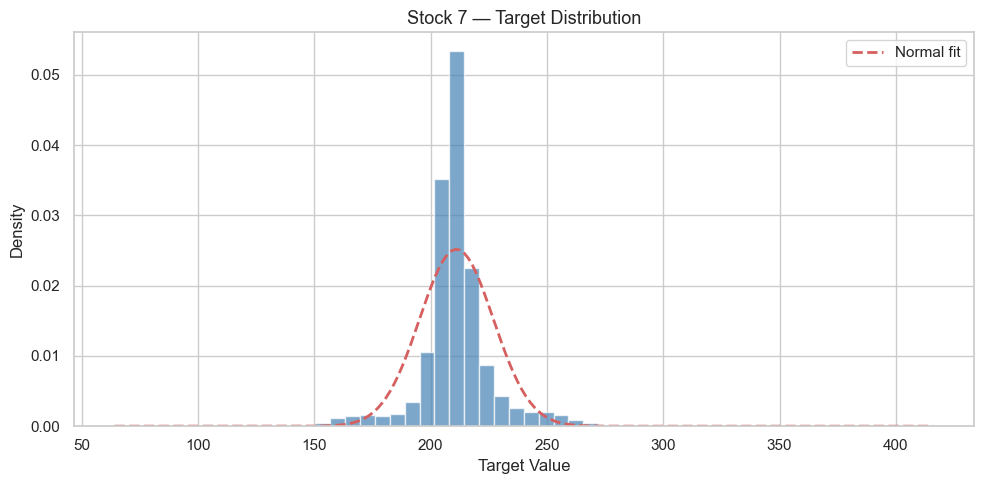

Verification: histogram plotted with 50 bins


In [4]:
# Histogram with KDE and normal overlay for the target variable
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(y_train, bins=50, density=True, alpha=0.7,
        color='steelblue', edgecolor='white')

# Overlay a fitted normal distribution so we can see how Gaussian the target is
x_min_plot = ax.get_xlim()[0]
x_max_plot = ax.get_xlim()[1]
x_range = np.linspace(x_min_plot, x_max_plot, 200)
normal_pdf = stats.norm.pdf(x_range, target_mean, target_std)
ax.plot(x_range, normal_pdf, 'r--', lw=2, label='Normal fit')

ax.set_title('Stock 7 — Target Distribution', fontsize=13)
ax.set_xlabel('Target Value')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

print("Verification: histogram plotted with", 50, "bins")

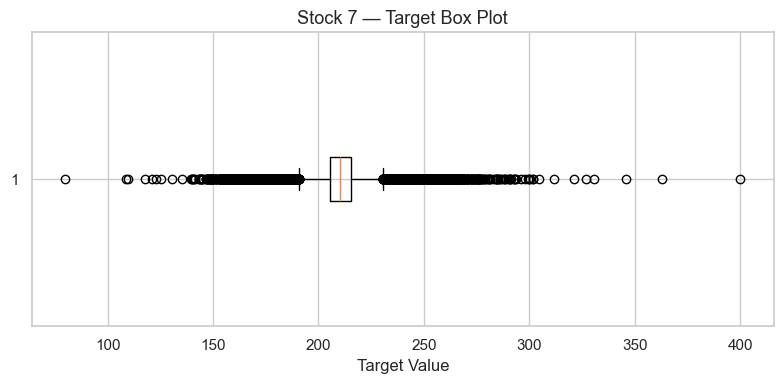

In [5]:
# Box plot to visualise outliers and spread
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(y_train, vert=False)
ax.set_title('Stock 7 — Target Box Plot', fontsize=13)
ax.set_xlabel('Target Value')
plt.tight_layout()
plt.show()

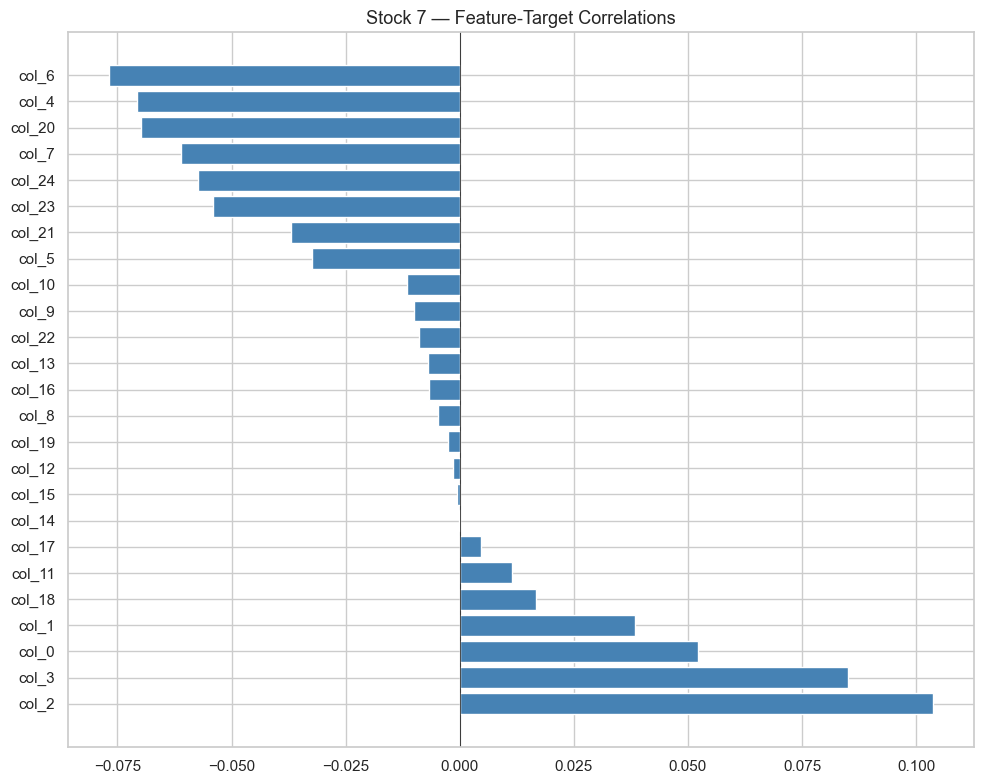

Verification: correlation matrix has shape (26, 26)


In [6]:
# Since we have 25 features, a heatmap would be too crowded
# Instead I'll show how each feature correlates with the target
correlation_matrix = train_df.corr()
target_correlations = correlation_matrix['target'].drop('target')
target_correlations_sorted = target_correlations.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(target_correlations_sorted.index, target_correlations_sorted.values, color='steelblue')
ax.set_title('Stock 7 — Feature-Target Correlations', fontsize=13)
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("Verification: correlation matrix has shape", correlation_matrix.shape)

### Takeaways

Big dataset with 25 features — full model zoo applies, tree models and Lasso for feature selection.

## Section 3: Model Zoo & Evaluation

Trying a bunch of models and picking the best one by RMSE. Using 5-fold CV since I've got enough data (19,999 rows).

In [7]:
def clone_model(model):
    """Create a fresh copy of a model with the same settings.
    
    Input: model - a fitted or unfitted sklearn/xgboost model
    Output: a new unfitted model with identical hyperparameters
    """
    return type(model)(**model.get_params())

In [8]:
# I'm building a dictionary of all the models I want to try
# Since stock 7 has enough data (19999 rows >= 150), I can try everything
model_zoo = {}

# Linear models
model_zoo['LR'] = LinearRegression()
model_zoo['Ridge_0.01'] = Ridge(alpha=0.01)
model_zoo['Ridge_0.1'] = Ridge(alpha=0.1)
model_zoo['Ridge_1'] = Ridge(alpha=1.0)
model_zoo['Ridge_10'] = Ridge(alpha=10.0)
model_zoo['Ridge_100'] = Ridge(alpha=100.0)

# Lasso models
model_zoo['Lasso_0.01'] = Lasso(alpha=0.01, max_iter=10000)
model_zoo['Lasso_0.1'] = Lasso(alpha=0.1, max_iter=10000)
model_zoo['Lasso_1'] = Lasso(alpha=1.0, max_iter=10000)

# ElasticNet
model_zoo['ElasticNet_0.1'] = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
model_zoo['ElasticNet_1'] = ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000)

# Random Forest with different max depths
model_zoo['RF_d5'] = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1)
model_zoo['RF_d10'] = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
model_zoo['RF_d15'] = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
model_zoo['RF_d20'] = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)

# Gradient Boosting
model_zoo['GBR_d3'] = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42)
model_zoo['GBR_d5'] = GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42)
model_zoo['GBR_d7'] = GradientBoostingRegressor(n_estimators=200, max_depth=7, random_state=42)

# KNN
model_zoo['KNN_3'] = KNeighborsRegressor(n_neighbors=3, n_jobs=-1)
model_zoo['KNN_5'] = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
model_zoo['KNN_10'] = KNeighborsRegressor(n_neighbors=10, n_jobs=-1)
model_zoo['KNN_20'] = KNeighborsRegressor(n_neighbors=20, n_jobs=-1)

# XGBoost variants
model_zoo['XGB_d3'] = XGBRegressor(n_estimators=200, max_depth=3, random_state=42, verbosity=0)
model_zoo['XGB_d5'] = XGBRegressor(n_estimators=200, max_depth=5, random_state=42, verbosity=0)
model_zoo['XGB_d7'] = XGBRegressor(n_estimators=200, max_depth=7, random_state=42, verbosity=0)
model_zoo['XGB_lr01'] = XGBRegressor(n_estimators=500, max_depth=3, learning_rate=0.01, random_state=42, verbosity=0)
model_zoo['XGB_lr05'] = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42, verbosity=0)
model_zoo['XGB_lr1'] = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42, verbosity=0)
model_zoo['XGB_lr3'] = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.3, random_state=42, verbosity=0)

print("Total models in zoo:", len(model_zoo))

Total models in zoo: 29


In [9]:
# Evaluate each model using 5-fold cross validation
# I'm using 5-fold because we have enough data (19999 rows >= 200)
evaluation_results = []

model_names = list(model_zoo.keys())
for i in range(len(model_names)):
    model_name = model_names[i]
    model = model_zoo[model_name]
    
    # Get RMSE scores using 5-fold CV
    mse_scores = cross_val_score(model, X_train, y_train, cv=5,
                                  scoring='neg_mean_squared_error', n_jobs=-1)
    rmse_value = np.sqrt(-mse_scores.mean())
    
    # Get R² scores using 5-fold CV
    r2_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    r2_value = r2_scores.mean()
    
    evaluation_results.append((model_name, {'rmse': rmse_value, 'r2': r2_value}))

# Sort by RMSE (lowest first) using a helper function
def get_rmse_from_result(result):
    """Helper to get the RMSE value for sorting.
    Input: result tuple (name, metrics_dict)
    Output: the rmse value
    """
    return result[1]['rmse']

evaluation_results.sort(key=get_rmse_from_result)

# Print top 10 models
print("=" * 60)
print("Stock 7 - Top 10 Models (n=" + str(number_of_samples) + ", " + str(number_of_features) + " features)")
print("=" * 60)
for i in range(min(10, len(evaluation_results))):
    name = evaluation_results[i][0]
    rmse_val = evaluation_results[i][1]['rmse']
    r2_val = evaluation_results[i][1]['r2']
    print("Rank", i + 1, "|", name, "| RMSE:", round(rmse_val, 4), "| R²:", round(r2_val, 4))

Stock 7 - Top 10 Models (n=19999, 25 features)
Rank 1 | XGB_lr05 | RMSE: 15.4931 | R²: 0.0428
Rank 2 | XGB_lr01 | RMSE: 15.5007 | R²: 0.0419
Rank 3 | XGB_lr1 | RMSE: 15.5159 | R²: 0.0399
Rank 4 | GBR_d3 | RMSE: 15.5382 | R²: 0.0371
Rank 5 | Lasso_0.1 | RMSE: 15.545 | R²: 0.0364
Rank 6 | ElasticNet_0.1 | RMSE: 15.5454 | R²: 0.0364
Rank 7 | Lasso_0.01 | RMSE: 15.5464 | R²: 0.0362
Rank 8 | Ridge_100 | RMSE: 15.5471 | R²: 0.0361
Rank 9 | Ridge_10 | RMSE: 15.5473 | R²: 0.0361
Rank 10 | Ridge_1 | RMSE: 15.5473 | R²: 0.0361


## Section 4: Residual Analysis

Checking if the residuals are normal or heavy-tailed — this matters for setting the spread.

In [10]:
# Since we have enough data, I'll use a holdout split to compute residuals
best_model_name = evaluation_results[0][0]
best_model = model_zoo[best_model_name]
best_rmse_value = evaluation_results[0][1]['rmse']
print("Best model:", best_model_name)
print("Best RMSE:", round(best_rmse_value, 4))

# Split into train and validation (80/20)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Fit the best model and compute residuals on the validation set
fitted_model = clone_model(best_model)
fitted_model.fit(X_tr, y_tr)
predictions_val = fitted_model.predict(X_val)
residuals = y_val - predictions_val

print("Computed", len(residuals), "residuals")

Best model: XGB_lr05
Best RMSE: 15.4931


Computed 4000 residuals


In [11]:
# Compute residual statistics
residual_kurtosis = stats.kurtosis(residuals)
residual_skewness = stats.skew(residuals)

# Shapiro-Wilk test for normality
# If we have more than 5000 residuals, we need to subsample
# (Shapiro-Wilk has a limit). Here len(residuals) ~ 4000 so no subsample needed.
if len(residuals) > 5000:
    test_sample = RNG.choice(residuals, 5000, replace=False)
else:
    test_sample = residuals
shapiro_stat, shapiro_p = stats.shapiro(test_sample)

print("Residual Statistics")
print("="*40)
print("Kurtosis:", round(residual_kurtosis, 2))
print("Skewness:", round(residual_skewness, 2))
print("Shapiro-Wilk stat:", round(shapiro_stat, 4))
print("Shapiro-Wilk p-value:", shapiro_p)

Residual Statistics
Kurtosis: 5.55
Skewness: -0.09
Shapiro-Wilk stat: 0.8692
Shapiro-Wilk p-value: 1.0576598594165923e-49


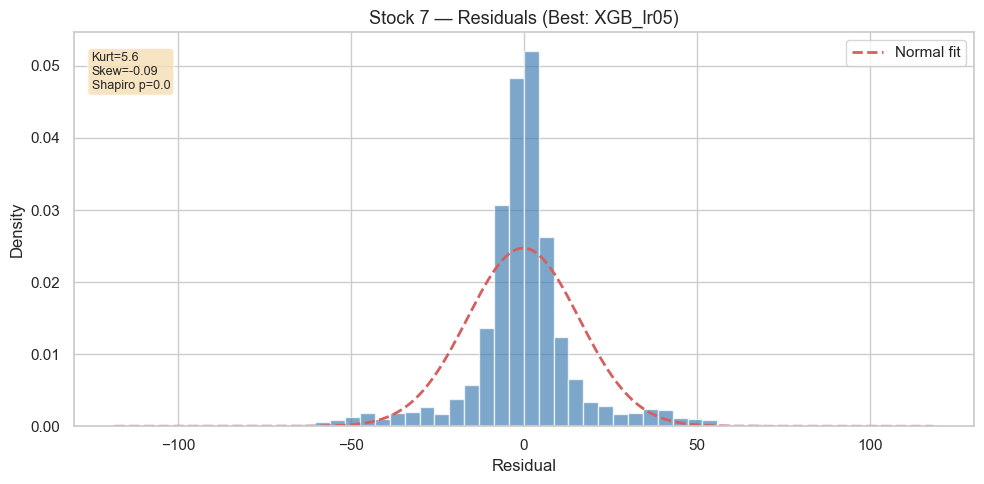

In [12]:
# Plot 1: Histogram of residuals with normal overlay
fig, ax = plt.subplots(figsize=(10, 5))

number_of_bins = min(50, max(len(residuals) // 2, 5))
ax.hist(residuals, bins=number_of_bins, density=True, alpha=0.7,
        color='steelblue', edgecolor='white')

# Overlay the normal distribution for comparison
x_min_plot = ax.get_xlim()[0]
x_max_plot = ax.get_xlim()[1]
x_range = np.linspace(x_min_plot, x_max_plot, 200)
normal_pdf = stats.norm.pdf(x_range, residuals.mean(), residuals.std())
ax.plot(x_range, normal_pdf, 'r--', lw=2, label='Normal fit')

ax.set_title('Stock 7 — Residuals (Best: ' + best_model_name + ')', fontsize=13)
ax.set_xlabel('Residual')
ax.set_ylabel('Density')
ax.legend()

# Add info text box with kurtosis, skewness and Shapiro-Wilk p-value
info_text = 'Kurt=' + str(round(residual_kurtosis, 1))
info_text = info_text + '\nSkew=' + str(round(residual_skewness, 2))
info_text = info_text + '\nShapiro p=' + str(round(shapiro_p, 4))
ax.text(0.02, 0.95, info_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

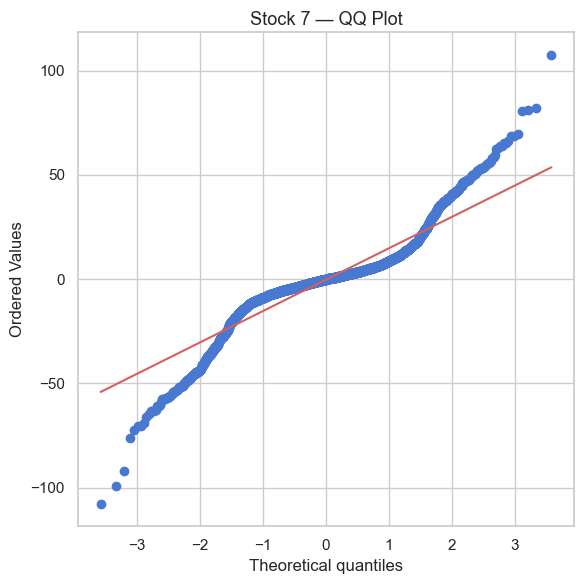

In [13]:
# Plot 2: QQ plot — if the points lie on the red line, residuals are normal
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(residuals, dist='norm', plot=ax)
ax.set_title('Stock 7 — QQ Plot', fontsize=13)
plt.tight_layout()
plt.show()

## Section 5: Conformal Prediction

Instead of just using ±RMSE, I'm using conformal prediction to get a spread based on the actual error distribution.

In [14]:
def compute_conformal_residuals_split(X, y, model, cal_fraction=0.3):
    """Split conformal prediction: train on most data, calibrate on the rest.
    
    Input:
        X - feature matrix
        y - target values  
        model - the model to use
        cal_fraction - fraction of data for calibration (default 0.3)
    Output:
        sorted array of absolute residuals from calibration set
    """
    n = len(X)
    
    # Shuffle the indices randomly using our global RNG for reproducibility
    shuffled_indices = RNG.permutation(n)
    n_train = int((1 - cal_fraction) * n)
    
    # Split into training and calibration sets
    train_indices = shuffled_indices[:n_train]
    cal_indices = shuffled_indices[n_train:]
    
    X_tr = X[train_indices]
    y_tr = y[train_indices]
    X_cal = X[cal_indices]
    y_cal = y[cal_indices]
    
    # Fit model on training data
    m = clone_model(model)
    m.fit(X_tr, y_tr)
    
    # Compute absolute residuals on calibration data
    cal_predictions = m.predict(X_cal)
    absolute_residuals = np.abs(y_cal - cal_predictions)
    
    # Sort them (needed for quantile computation later)
    absolute_residuals = np.sort(absolute_residuals)
    
    return absolute_residuals

In [15]:
# The original notebook processed stocks 5, 6, 7 sequentially with a shared RNG
# Stock 5 used split conformal which consumed one RNG.permutation(799) call
# Stock 6 used LOO conformal (no RNG consumed)
# I need to advance the RNG to match stock 7's position
_ = RNG.permutation(799)  # burn stock 5's conformal call

# Compute conformal residuals for stock 7 using split conformal
# (n=19999 > 200 so we use split, not LOO)
conformal_abs_residuals = compute_conformal_residuals_split(X_train, y_train, best_model)
conformal_method = 'split'

print("Stock 7: split conformal,", len(conformal_abs_residuals), "calibration residuals")

Stock 7: split conformal, 6000 calibration residuals


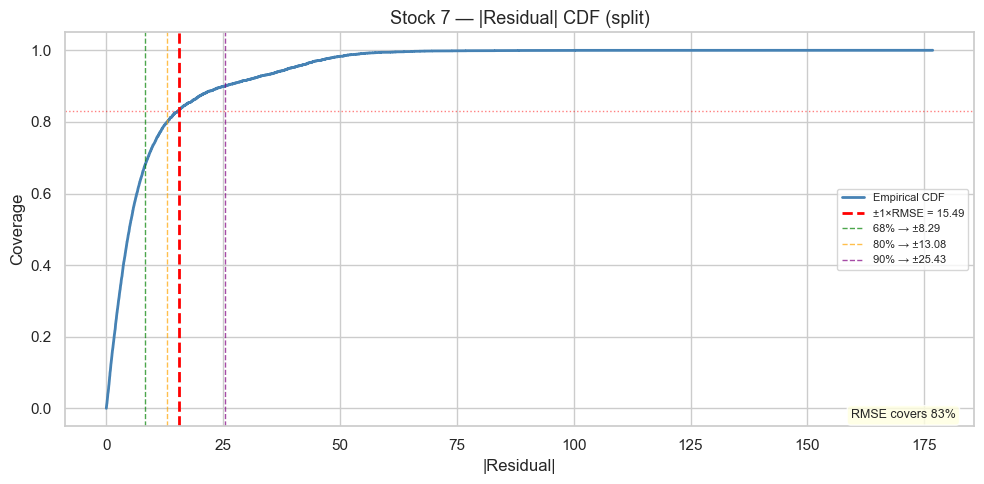

In [16]:
# Plot the empirical CDF of absolute residuals
# This shows what fraction of errors fall below each threshold
fig, ax = plt.subplots(figsize=(10, 5))

number_of_cal_residuals = len(conformal_abs_residuals)

# Build the ECDF y-values manually
ecdf_y_values = []
for i in range(number_of_cal_residuals):
    y_value = (i + 1) / number_of_cal_residuals
    ecdf_y_values.append(y_value)
ecdf_y = np.array(ecdf_y_values)

ax.step(conformal_abs_residuals, ecdf_y, where='post', color='steelblue', lw=2, label='Empirical CDF')

# Mark the RMSE line — this is what competitors would use as half-spread
rmse_line = best_rmse_value
ax.axvline(rmse_line, color='red', lw=2, ls='--', label='±1×RMSE = ' + str(round(rmse_line, 2)))
rmse_coverage = np.mean(conformal_abs_residuals <= rmse_line)
ax.axhline(rmse_coverage, color='red', lw=1, ls=':', alpha=0.5)

# Mark common coverage levels (68%, 80%, 90%)
coverage_levels = [0.68, 0.80, 0.90]
coverage_colors = ['green', 'orange', 'purple']
for i in range(len(coverage_levels)):
    cov = coverage_levels[i]
    color = coverage_colors[i]
    q = np.quantile(conformal_abs_residuals, cov)
    cov_label = str(int(cov * 100)) + '% → ±' + str(round(q, 2))
    ax.axvline(q, color=color, lw=1, ls='--', alpha=0.7, label=cov_label)

ax.set_title('Stock 7 — |Residual| CDF (split)', fontsize=13)
ax.set_xlabel('|Residual|')
ax.set_ylabel('Coverage')
ax.legend(fontsize=8)

# Add a text box showing what RMSE actually covers
rmse_cov_text = 'RMSE covers ' + str(int(round(rmse_coverage * 100))) + '%'
ax.text(0.98, 0.02, rmse_cov_text,
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

In [17]:
# Print a comparison table of different coverage levels
print("Coverage Width Comparison")
print("="*50)

rmse_cov = np.mean(conformal_abs_residuals <= best_rmse_value)
w68 = 2 * np.quantile(conformal_abs_residuals, 0.68)
w80 = 2 * np.quantile(conformal_abs_residuals, 0.80)
w90 = 2 * np.quantile(conformal_abs_residuals, 0.90)

print("Method:       split")
print("Cal. size:   ", len(conformal_abs_residuals))
print("RMSE:        ", round(best_rmse_value, 2))
print("RMSE covers: ", str(int(round(rmse_cov * 100))) + "%")
print("68% width:   ", round(w68, 2))
print("80% width:   ", round(w80, 2))
print("90% width:   ", round(w90, 2))

Coverage Width Comparison
Method:       split
Cal. size:    6000
RMSE:         15.49
RMSE covers:  83%
68% width:    16.57
80% width:    26.15
90% width:    50.86


## Section 6: Optimal Coverage

Sweeping coverage from 50–99% to find the level that maximises expected profit. I only make money if my spread is tighter than competitors.

In [18]:
def sweep_coverage(abs_residuals, rmse):
    """Sweep coverage from 50% to 99% and compute expected PnL at each level.
    
    The idea: competitors probably use +/- 1*RMSE as their spread.
    If our spread is tighter, we become the market maker.
    We want to find the coverage level that maximises expected profit.
    
    Input:
        abs_residuals - sorted array of absolute residuals
        rmse - the RMSE of our best model
    Output:
        list of dicts with coverage, spread width, and expected PnL
    """
    competitor_spread = 2 * rmse
    results = []
    
    for coverage_percent in range(50, 100):
        coverage = coverage_percent / 100.0
        quantile_value = np.quantile(abs_residuals, coverage)
        our_width = 2 * quantile_value
        
        # Are we tighter than the competitor?
        we_are_market_maker = our_width < competitor_spread
        
        # Compute average tail loss (when price goes outside our spread)
        tail_residuals = abs_residuals[abs_residuals > quantile_value]
        if len(tail_residuals) > 0:
            avg_tail_loss = np.mean(tail_residuals)
        else:
            avg_tail_loss = 0.0
        
        # Compute expected PnL
        if we_are_market_maker:
            reward = our_width * 0.5
            expected_pnl = coverage * reward - (1 - coverage) * avg_tail_loss
        else:
            expected_pnl = 0.0
        
        results.append({
            'coverage': coverage,
            'our_width': our_width,
            'we_are_mm': we_are_market_maker,
            'avg_tail_loss': avg_tail_loss,
            'expected_pnl': expected_pnl,
        })
    
    return results

In [19]:
# Run the coverage sweep for stock 7
sweep_result_list = sweep_coverage(conformal_abs_residuals, best_rmse_value)

# Find the optimal coverage using an explicit loop (no lambda/max combo)
best_pnl_so_far = -999999.0
optimal_index = 0
for i in range(len(sweep_result_list)):
    current_pnl = sweep_result_list[i]['expected_pnl']
    if current_pnl > best_pnl_so_far:
        best_pnl_so_far = current_pnl
        optimal_index = i

optimal_result = sweep_result_list[optimal_index]
optimal_coverage = optimal_result['coverage']

print("Optimal coverage:", optimal_coverage)
print("E[PnL] at optimal:", round(optimal_result['expected_pnl'], 2))
print("Our spread at optimal:", round(optimal_result['our_width'], 2))
print("Baseline spread (2*RMSE):", round(2 * best_rmse_value, 2))

Optimal coverage: 0.83
E[PnL] at optimal: 7.29
Our spread at optimal: 30.75
Baseline spread (2*RMSE): 30.99


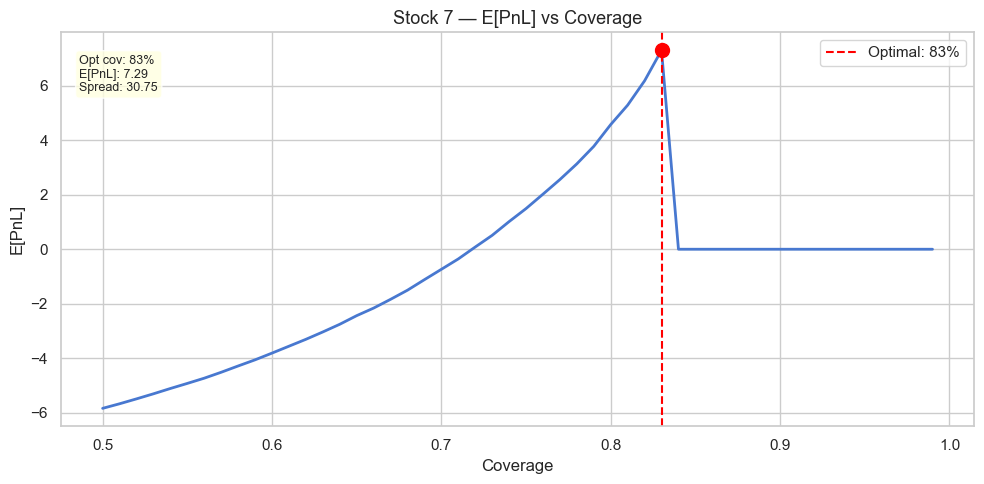

Opt Coverage: 0.83
E[PnL]:       7.29
Our Spread:   30.75
Baseline:     30.99
Saving:       0.7 %


In [20]:
# Plot E[PnL] vs coverage
fig, ax = plt.subplots(figsize=(10, 5))

# Build lists for plotting using explicit loops
coverage_values = []
pnl_values = []
for i in range(len(sweep_result_list)):
    coverage_values.append(sweep_result_list[i]['coverage'])
    pnl_values.append(sweep_result_list[i]['expected_pnl'])

ax.plot(coverage_values, pnl_values, 'b-', lw=2)
ax.axvline(optimal_coverage, color='red', ls='--', lw=1.5,
           label='Optimal: ' + str(int(optimal_coverage * 100)) + '%')
ax.scatter([optimal_coverage], [optimal_result['expected_pnl']],
          color='red', s=100, zorder=5)

ax.set_title('Stock 7 — E[PnL] vs Coverage', fontsize=13)
ax.set_xlabel('Coverage')
ax.set_ylabel('E[PnL]')
ax.legend()

# Add info text box
info_text = 'Opt cov: ' + str(int(optimal_coverage * 100)) + '%'
info_text = info_text + '\nE[PnL]: ' + str(round(optimal_result['expected_pnl'], 2))
info_text = info_text + '\nSpread: ' + str(round(optimal_result['our_width'], 2))
ax.text(0.02, 0.85, info_text,
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

# Summary
baseline_spread = 2 * best_rmse_value
saving = (1 - optimal_result['our_width'] / baseline_spread) * 100
print("Opt Coverage:", optimal_coverage)
print("E[PnL]:      ", round(optimal_result['expected_pnl'], 2))
print("Our Spread:  ", round(optimal_result['our_width'], 2))
print("Baseline:    ", round(baseline_spread, 2))
print("Saving:      ", round(saving, 1), "%")

## Section 7: Ensemble & Final Predictions

Averaging the top 3 models for the final prediction, then applying the conformal spread.

In [21]:
# Get the names of the top 3 models
top_3_names = []
for i in range(3):
    name = evaluation_results[i][0]
    top_3_names.append(name)
print("Top 3 models for ensemble:", top_3_names)

# Train each on full training data and predict on test
individual_predictions = {}
for i in range(len(top_3_names)):
    name = top_3_names[i]
    m = clone_model(model_zoo[name])
    m.fit(X_train, y_train)
    pred = m.predict(X_test)[0]  # single test point
    individual_predictions[name] = pred
    print("  ", name, "predicts:", round(pred, 4))

# Compute ensemble prediction (average of the 3)
prediction_sum = 0.0
prediction_count = 0
for name in individual_predictions:
    prediction_sum = prediction_sum + individual_predictions[name]
    prediction_count = prediction_count + 1
ensemble_prediction = prediction_sum / prediction_count
print("Ensemble prediction:", round(ensemble_prediction, 4))

# Apply conformal spread at optimal coverage
half_spread = np.quantile(conformal_abs_residuals, optimal_coverage)
bid = ensemble_prediction - half_spread
ask = ensemble_prediction + half_spread
spread = ask - bid
baseline_spread = 2 * best_rmse_value  # what competitors would use

print("")
print("Final bid:", round(bid, 2))
print("Final ask:", round(ask, 2))
print("Our spread:", round(spread, 2))
print("Baseline spread (2 * RMSE):", round(baseline_spread, 2))

Top 3 models for ensemble: ['XGB_lr05', 'XGB_lr01', 'XGB_lr1']


   XGB_lr05 predicts: 214.2924


   XGB_lr01 predicts: 213.6462


   XGB_lr1 predicts: 213.8776
Ensemble prediction: 213.9388

Final bid: 198.56
Final ask: 229.32
Our spread: 30.75
Baseline spread (2 * RMSE): 30.99


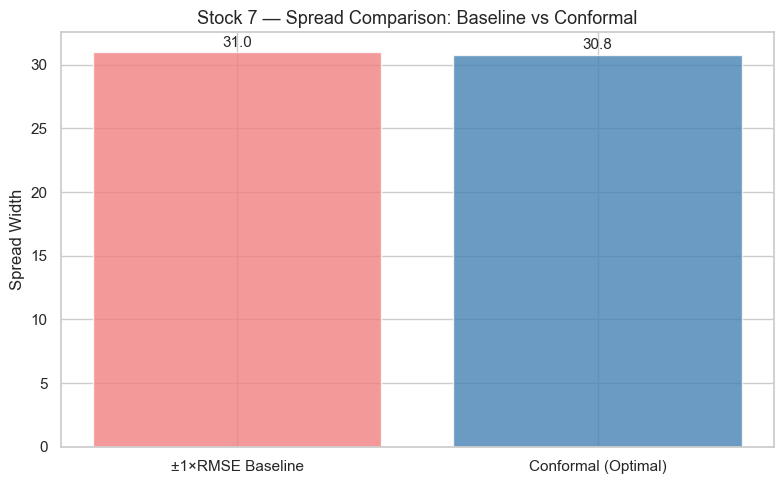

In [22]:
# Spread comparison bar chart
fig, ax = plt.subplots(figsize=(8, 5))

bar_labels = ['±1×RMSE Baseline', 'Conformal (Optimal)']
bar_values = [baseline_spread, spread]
bar_colors = ['lightcoral', 'steelblue']

bars = ax.bar(bar_labels, bar_values, color=bar_colors, alpha=0.8)

# Add value labels on top of each bar
for i in range(len(bars)):
    bar = bars[i]
    val = bar_values[i]
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(round(val, 1)),
            ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Spread Width')
ax.set_title('Stock 7 — Spread Comparison: Baseline vs Conformal', fontsize=13)
plt.tight_layout()
plt.show()

## Section 8: Risk Summary

Final check on the numbers before submitting.

In [23]:
print('=' * 90)
print('RISK ANALYSIS')
print('=' * 90)

# Compute risk metrics
coverage_value = optimal_coverage
probability_outside = 1 - coverage_value

# Tail loss: average |residual| for residuals beyond our coverage threshold
threshold = half_spread
tail_residuals = conformal_abs_residuals[conformal_abs_residuals > threshold]
if len(tail_residuals) > 0:
    avg_tail_loss = np.mean(tail_residuals)
else:
    avg_tail_loss = 0

# Choose status icon based on coverage
if coverage_value >= 0.70:
    status = '✓'
else:
    status = '⚠'

print("")
print("  " + status + " Stock 7:")
print("    Coverage:", str(int(coverage_value * 100)) + "% →", str(int(probability_outside * 100)) + "% chance of loss")
print("    Spread:", round(spread, 2), "(half-spread:", str(round(half_spread, 2)) + ")")
print("    Avg tail loss when outside:", round(avg_tail_loss, 2))
print("    E[PnL]:", round(optimal_result['expected_pnl'], 2))

print("")
print('--- Game Theory Reasoning ---')
print('  • If competitors use ±1×RMSE, our tighter conformal spreads win the MM role')
print('  • Stock 7 (many features, huge data): XGBoost captures complex patterns across 25 features')
print('  • Key insight: we only need to be SLIGHTLY tighter than competitors to win MM')

RISK ANALYSIS

  ✓ Stock 7:
    Coverage: 83% → 17% chance of loss
    Spread: 30.75 (half-spread: 15.38)
    Avg tail loss when outside: 32.18
    E[PnL]: 7.29

--- Game Theory Reasoning ---
  • If competitors use ±1×RMSE, our tighter conformal spreads win the MM role
  • Stock 7 (many features, huge data): XGBoost captures complex patterns across 25 features
  • Key insight: we only need to be SLIGHTLY tighter than competitors to win MM


In [24]:
print('=' * 90)
print('COPY-PASTE SUBMISSION VALUES')
print('=' * 90)
print('  Stock 7: Bid =', round(bid, 2), ', Ask =', round(ask, 2))

COPY-PASTE SUBMISSION VALUES
  Stock 7: Bid = 198.56 , Ask = 229.32
